In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

In [2]:
PROJECT_DIR = Path.cwd().resolve().parent

PROCESSED_DIR = (
    PROJECT_DIR /
    'data' /
    'processed'
)

master_df = pd.read_parquet(
    PROCESSED_DIR /
    'master_dataset.parquet'
)

master_df.shape

(30735648, 34)

# Dataset Overview

In [3]:
print("Shape :", master_df.shape)
print("Rows  :", f"{len(master_df):,}")
print("Cols  :", len(master_df.columns))

Shape : (30735648, 34)
Rows  : 30,735,648
Cols  : 34


In [4]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30735648 entries, 0 to 30735647
Data columns (total 34 columns):
 #   Column                                       Dtype              
---  ------                                       -----              
 0   Household_ID                                 int64              
 1   AffectsTimePoint                             str                
 2   Group_x                                      str                
 3   Timestamp                                    datetime64[us, UTC]
 4   kWh_received_Total                           float64            
 5   kWh_received_HeatPump                        float64            
 6   kWh_received_Other                           float64            
 7   Group_y                                      str                
 8   Weather_ID                                   str                
 9   Installation_HasPVSystem                     object             
 10  Protocols_Available                          bool  

In [5]:
memory_mb = (
    master_df.memory_usage(
        deep=True
    ).sum()
    /1024**2
)

print(
    f"Memory usage: {memory_mb:.2f} MB"
)

Memory usage: 14384.00 MB


In [6]:
master_df['Household_ID'].nunique()

300

In [7]:
print(
    master_df['Timestamp'].min()
)

print(
    master_df['Timestamp'].max()
)

2019-05-20 00:00:00+00:00
2024-02-27 23:45:00+00:00


In [8]:
master_df['Weather_ID'].nunique()

8

In [9]:
household_obs = (
    master_df
    .groupby('Household_ID')
    .size()
    .reset_index(name='n_obs')
)

household_obs.describe()

,Household_ID,n_obs
count,3.000000e+02,300.000000
mean,2.115425e+06,102452.160000
std,2.928375e+06,28160.926463
min,1.026600e+04,14976.000000
25%,4.626168e+05,82344.000000
50%,8.277865e+05,106608.000000
75%,1.167550e+06,118872.000000
max,9.981041e+06,160800.000000


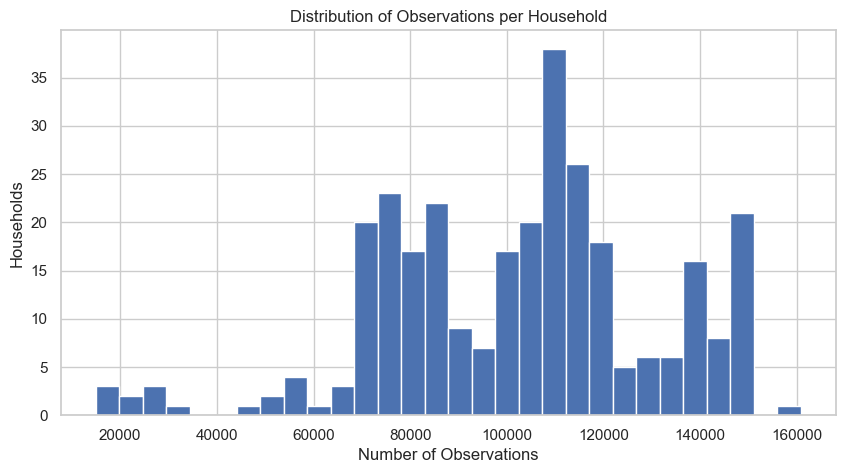

In [10]:
plt.figure(figsize=(10,5))

plt.hist(
    household_obs['n_obs'],
    bins=30
)

plt.xlabel('Number of Observations')
plt.ylabel('Households')
plt.title(
    'Distribution of Observations per Household'
)

plt.show()

# Missing Value Analysis

In [11]:
missing_df = pd.DataFrame({
    'missing_count': master_df.isnull().sum(),
    'missing_percent':
        master_df.isnull().mean()*100
})

missing_df = (
    missing_df
    .sort_values(
        'missing_percent',
        ascending=False
    )
)

missing_df

,missing_count,missing_percent
kWh_received_HeatPump,30067200,97.825170
kWh_received_Other,30065184,97.818611
Survey_DHW_Production_BySolar,28076544,91.348469
Survey_DHW_Production_ByElectricWaterHeater,22865472,74.393981
Protocols_ReportIDs,20041728,65.206785
Installation_HasPVSystem,14736864,47.947139
Survey_DHW_Production_ByHeatPump,10705824,34.831945
Survey_Installation_HasElectricVehicle,8959008,29.148590
Survey_HeatDistribution_System_Radiator,3495072,11.371395
Survey_HeatDistribution_System_FloorHeating,3495072,11.371395


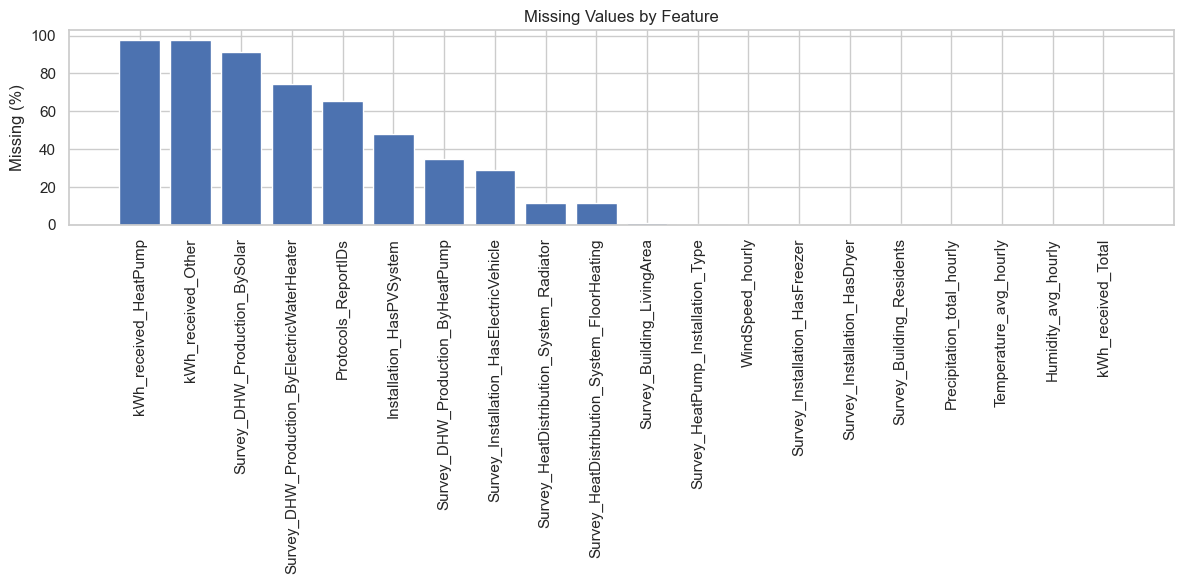

In [12]:
missing_plot = (
    missing_df[
        missing_df['missing_count'] > 0
    ]
)

plt.figure(figsize=(12,6))

plt.bar(
    missing_plot.index,
    missing_plot['missing_percent']
)

plt.xticks(rotation=90)
plt.ylabel('Missing (%)')
plt.title('Missing Values by Feature')

plt.tight_layout()
plt.show()

In [13]:
master_df[
    [
        'kWh_received_Total',
        'kWh_received_HeatPump',
        'kWh_received_Other'
    ]
].isnull().sum()

kWh_received_Total           2208
kWh_received_HeatPump    30067200
kWh_received_Other       30065184
dtype: int64

In [14]:
household_missing = (
    master_df
    .groupby('Household_ID')
    .apply(
        lambda x:
        x.isnull().mean().mean()*100
    )
    .reset_index(
        name='missing_percent'
    )
)

household_missing.describe()

,Household_ID,missing_percent
count,3.000000e+02,300.000000
mean,2.115425e+06,17.051027
std,2.928375e+06,2.740949
min,1.026600e+04,6.060606
25%,4.626168e+05,15.164691
50%,8.277865e+05,18.181818
75%,1.167550e+06,18.199578
max,9.981041e+06,34.906355


In [15]:
master_df['kWh_received_HeatPump'].notna().mean()*100

2.174829696123537

In [16]:
master_df[
    master_df['kWh_received_HeatPump'].notna()
]['Household_ID'].nunique()

7

In [17]:
master_df[
    master_df['kWh_received_HeatPump'].notna()
][
    ['Household_ID']
].drop_duplicates()

,Household_ID
2323680,108511
2770848,109105
4188288,114109
14729568,818882
18227136,998988
18645408,1009851
24846720,5657284


In [18]:
master_df.groupby('Household_ID')[
    'kWh_received_HeatPump'
].apply(
    lambda x: x.notna().mean()*100
).sort_values()

Household_ID
10266        0.000000
1091151      0.000000
1090081      0.000000
1088811      0.000000
1084671      0.000000
              ...    
114109      99.586492
5657284     99.738220
109105      99.909420
108511     100.000000
818882     100.000000
Name: kWh_received_HeatPump, Length: 300, dtype: float64

# Duplicate Analysis

In [19]:
master_df.duplicated().sum()

0

In [20]:
master_df.duplicated(
    subset=['Household_ID', 'Timestamp']
).sum()

0

In [21]:
master_df[
    master_df.duplicated(
        subset=['Household_ID', 'Timestamp'],
        keep=False
    )
].sort_values(
    ['Household_ID', 'Timestamp']
)

,Household_ID,AffectsTimePoint,Group_x,Timestamp,kWh_received_Total,kWh_received_HeatPump,kWh_received_Other,Group_y,Weather_ID,Installation_HasPVSystem,Protocols_Available,Protocols_HasMultipleVisits,Protocols_ReportIDs,MetaData_Available,SmartMeterData_Available_15min,SmartMeterData_Available_Daily,SmartMeterData_Available_Monthly,Survey_Building_Type,Survey_Building_LivingArea,Survey_Building_Residents,Survey_HeatPump_Installation_Type,Survey_HeatDistribution_System_FloorHeating,Survey_HeatDistribution_System_Radiator,Survey_DHW_Production_ByHeatPump,Survey_DHW_Production_ByElectricWaterHeater,Survey_DHW_Production_BySolar,Survey_Installation_HasDryer,Survey_Installation_HasFreezer,Survey_Installation_HasElectricVehicle,Timestamp_hour,Temperature_avg_hourly,Humidity_avg_hourly,Precipitation_total_hourly,WindSpeed_hourly


# Analisis Target (kWh_received_Total)

In [22]:
master_df['kWh_received_Total'].describe()

count    3.073344e+07
mean     3.027392e-01
std      4.036858e-01
min      0.000000e+00
25%      5.600000e-02
50%      1.340000e-01
75%      4.100000e-01
max      6.697600e+01
Name: kWh_received_Total, dtype: float64

In [23]:
master_df['kWh_received_Total'].isna().mean()*100

0.0071838407311275825

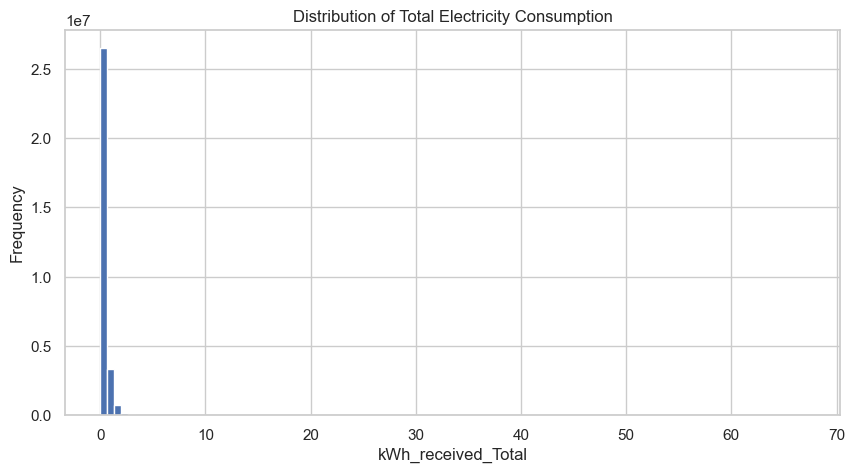

In [24]:
plt.figure(figsize=(10,5))

plt.hist(
    master_df['kWh_received_Total'].dropna(),
    bins=100
)

plt.xlabel('kWh_received_Total')
plt.ylabel('Frequency')
plt.title('Distribution of Total Electricity Consumption')

plt.show()

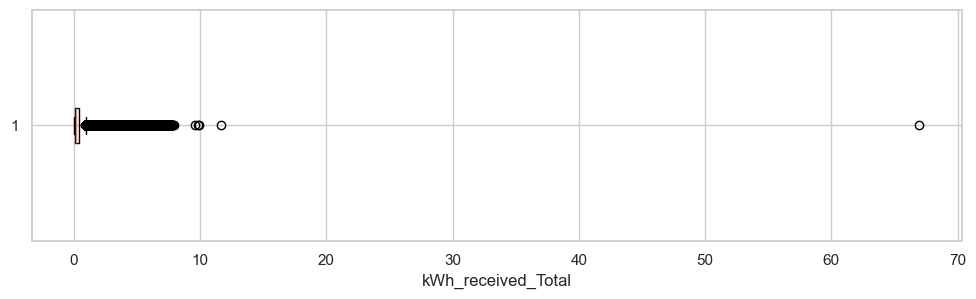

In [25]:
plt.figure(figsize=(12,3))

plt.boxplot(
    master_df['kWh_received_Total'].dropna(),
    vert=False
)

plt.xlabel('kWh_received_Total')

plt.show()

In [26]:
(
    master_df['kWh_received_Total'] == 0
).mean()*100

3.6552670046195215

In [27]:
target_household = (
    master_df
    .groupby('Household_ID')
    ['kWh_received_Total']
    .agg(
        ['mean','median','std','max']
    )
)

target_household.describe()

,mean,median,std,max
count,300.000000,300.000000,300.000000,300.000000
mean,0.306525,0.161933,0.350076,3.431897
std,0.150268,0.132252,0.140190,3.934005
min,0.061866,0.002000,0.084963,1.162000
25%,0.206157,0.078750,0.255343,2.293500
50%,0.277859,0.125000,0.326243,2.889500
75%,0.371242,0.196000,0.430147,3.862500
max,1.050566,0.898000,1.178225,66.976000


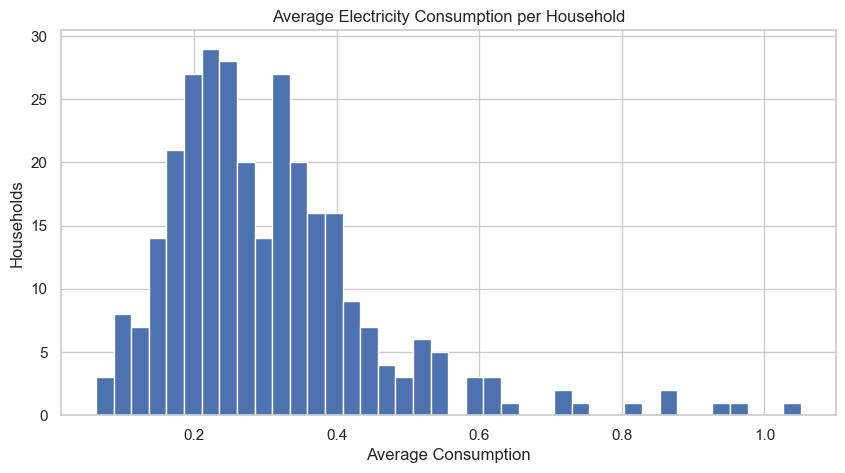

In [28]:
plt.figure(figsize=(10,5))

plt.hist(
    target_household['mean'],
    bins=40
)

plt.xlabel('Average Consumption')
plt.ylabel('Households')
plt.title('Average Electricity Consumption per Household')

plt.show()

# Time Series Pattern

In [29]:
master_df['hour'] = (
    master_df['Timestamp']
    .dt.hour
)

master_df['dayofweek'] = (
    master_df['Timestamp']
    .dt.dayofweek
)

master_df['month'] = (
    master_df['Timestamp']
    .dt.month
)

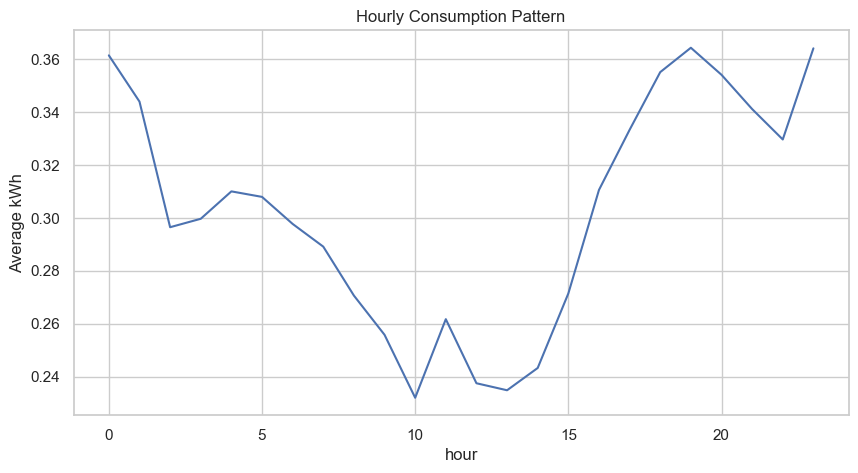

In [30]:
hour_pattern = (
    master_df
    .groupby('hour')
    ['kWh_received_Total']
    .mean()
)

hour_pattern.plot(
    figsize=(10,5)
)

plt.ylabel('Average kWh')
plt.title('Hourly Consumption Pattern')

plt.show()

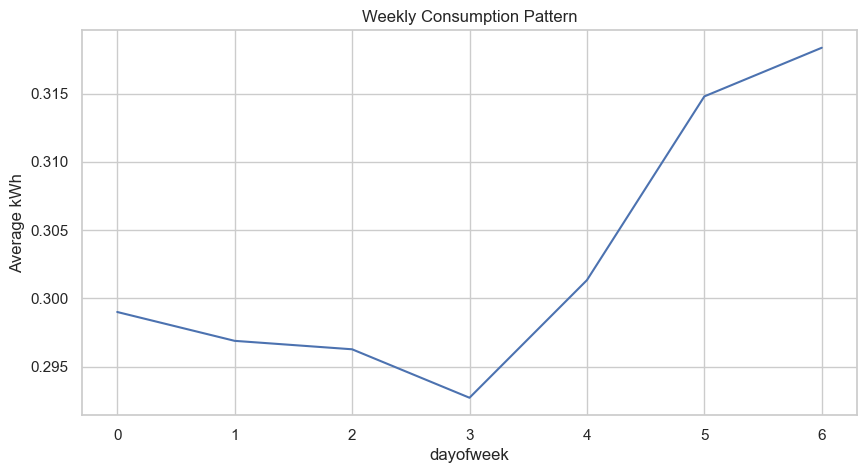

In [31]:
week_pattern = (
    master_df
    .groupby('dayofweek')
    ['kWh_received_Total']
    .mean()
)

week_pattern.plot(
    figsize=(10,5)
)

plt.ylabel('Average kWh')
plt.title('Weekly Consumption Pattern')

plt.show()

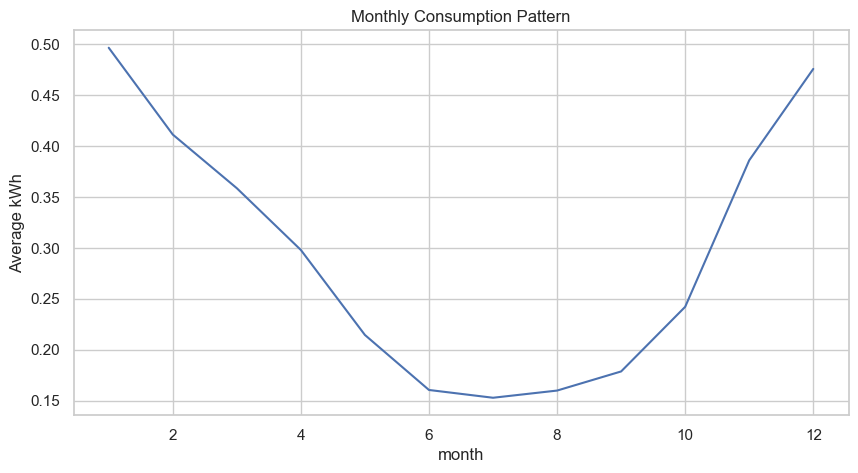

In [32]:
month_pattern = (
    master_df
    .groupby('month')
    ['kWh_received_Total']
    .mean()
)

month_pattern.plot(
    figsize=(10,5)
)

plt.ylabel('Average kWh')
plt.title('Monthly Consumption Pattern')

plt.show()

# Analisis Outlier

In [33]:
Q1 = master_df['kWh_received_Total'].quantile(0.25)
Q3 = master_df['kWh_received_Total'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower :", lower)
print("Upper :", upper)

Lower : -0.4749999999999999
Upper : 0.9409999999999998


In [34]:
outlier_mask = (
    (master_df['kWh_received_Total'] < lower)
    |
    (master_df['kWh_received_Total'] > upper)
)

outlier_mask.mean() * 100

7.100136623115934

In [35]:
master_df[
    outlier_mask
].sort_values(
    'kWh_received_Total',
    ascending=False
)[
    [
        'Household_ID',
        'Timestamp',
        'kWh_received_Total'
    ]
].head(20)

,Household_ID,Timestamp,kWh_received_Total
10072412,676510,2021-01-09 23:00:00+00:00,66.976
13600316,771207,2021-01-09 23:00:00+00:00,11.643
5253116,116977,2021-01-08 23:00:00+00:00,9.914
11502428,712718,2021-09-26 23:00:00+00:00,9.834
2686282,109104,2021-09-27 02:30:00+00:00,9.573
9522719,664610,2020-03-26 23:45:00+00:00,7.886
9527527,664610,2020-05-16 01:45:00+00:00,7.830
9525990,664610,2020-04-30 01:30:00+00:00,7.775
9542023,664610,2020-10-14 01:45:00+00:00,7.771
9527335,664610,2020-05-14 01:45:00+00:00,7.768


# Korelasi dengan Cuaca

In [36]:
weather_corr = (
    master_df[
        [
            'kWh_received_Total',
            'Temperature_avg_hourly',
            'Humidity_avg_hourly',
            'Precipitation_total_hourly',
            'WindSpeed_hourly'
        ]
    ]
    .corr()
)

weather_corr

,kWh_received_Total,Temperature_avg_hourly,Humidity_avg_hourly,Precipitation_total_hourly,WindSpeed_hourly
kWh_received_Total,1.000000,-0.324582,0.132078,0.002284,0.011716
Temperature_avg_hourly,-0.324582,1.000000,-0.541780,0.001347,0.074698
Humidity_avg_hourly,0.132078,-0.541780,1.000000,0.143650,-0.329275
Precipitation_total_hourly,0.002284,0.001347,0.143650,1.000000,0.105289
WindSpeed_hourly,0.011716,0.074698,-0.329275,0.105289,1.000000


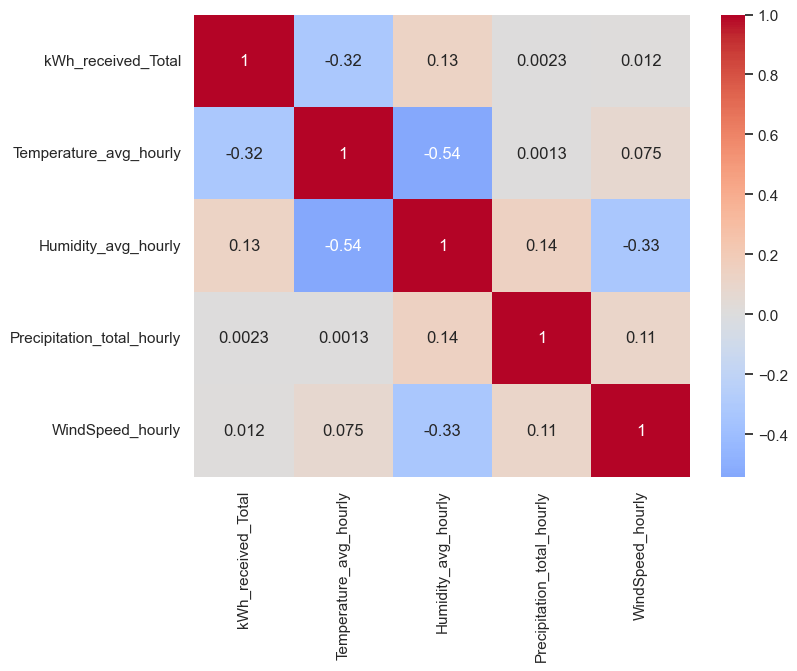

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    weather_corr,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.show()

# Pengaruh Musim (Seasonality)

In [38]:
monthly_consumption = (
    master_df
    .groupby('month')
    ['kWh_received_Total']
    .agg(
        ['mean','median','std']
    )
)

monthly_consumption

,mean,median,std
month,,,
1,0.496359,0.369,0.488914
2,0.411183,0.254,0.452820
3,0.358517,0.191,0.436012
4,0.297897,0.139,0.397946
5,0.214507,0.095,0.328974
6,0.160535,0.075,0.266573
7,0.152904,0.072,0.258260
8,0.159951,0.075,0.267404
9,0.178715,0.083,0.287360


In [39]:
hourly_consumption = (
    master_df
    .groupby('hour')
    ['kWh_received_Total']
    .agg(
        ['mean','median','std']
    )
)

hourly_consumption

,mean,median,std
hour,,,
0,0.361451,0.126,0.508727
1,0.343969,0.116,0.503889
2,0.296474,0.109,0.433492
3,0.299662,0.118,0.422197
4,0.310022,0.136,0.404060
5,0.307941,0.145,0.378687
6,0.297714,0.142,0.358984
7,0.289125,0.134,0.356253
8,0.270622,0.121,0.347392


# Pengaruh Karakteristik Rumah

In [40]:
master_df.groupby(
    'Survey_Building_Type'
)['kWh_received_Total'].mean().sort_values(
    ascending=False
)

Survey_Building_Type
house         0.303827
appartment    0.190303
Name: kWh_received_Total, dtype: float64

In [41]:
master_df[
    [
        'Survey_Building_LivingArea',
        'kWh_received_Total'
    ]
].corr()

,Survey_Building_LivingArea,kWh_received_Total
Survey_Building_LivingArea,1.000000,0.176379
kWh_received_Total,0.176379,1.000000


In [42]:
master_df[
    [
        'Survey_Building_Residents',
        'kWh_received_Total'
    ]
].corr()

,Survey_Building_Residents,kWh_received_Total
Survey_Building_Residents,1.000000,0.037504
kWh_received_Total,0.037504,1.000000


# Pengaruh Heat Pump

In [43]:
master_df.groupby(
    'Survey_HeatPump_Installation_Type'
)['kWh_received_Total'].agg(
    ['mean','median','count']
)

,mean,median,count
Survey_HeatPump_Installation_Type,,,
air-source,0.309559,0.137,18559200
ground-source,0.289087,0.130,11999040


In [44]:
(
    master_df
    .groupby(
        'Survey_HeatPump_Installation_Type'
    )
    ['kWh_received_Total']
    .mean()
    .sort_values()
)

Survey_HeatPump_Installation_Type
ground-source    0.289087
air-source       0.309559
Name: kWh_received_Total, dtype: float64

# Analisis Missing Per Household

In [45]:
household_missing = (
    master_df
    .groupby('Household_ID')
    .apply(
        lambda x:
        x.isnull().mean().mean()*100
    )
    .reset_index(
        name='missing_percent'
    )
)

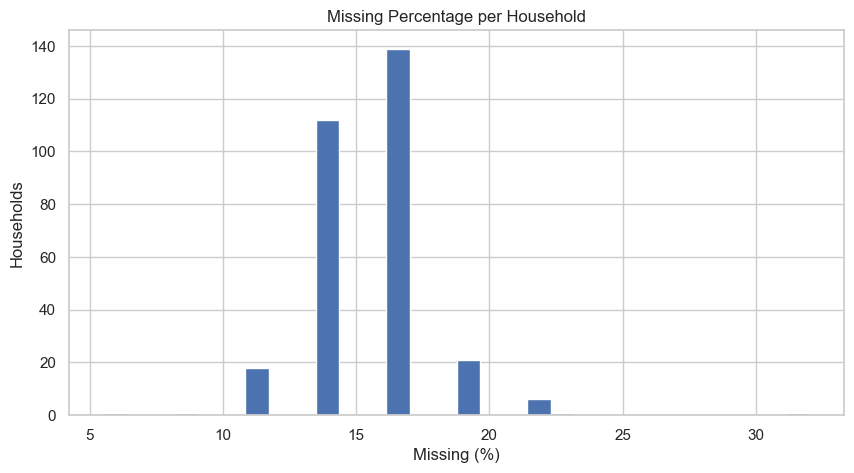

In [46]:
plt.figure(figsize=(10,5))

plt.hist(
    household_missing['missing_percent'],
    bins=30
)

plt.xlabel('Missing (%)')
plt.ylabel('Households')
plt.title('Missing Percentage per Household')

plt.show()

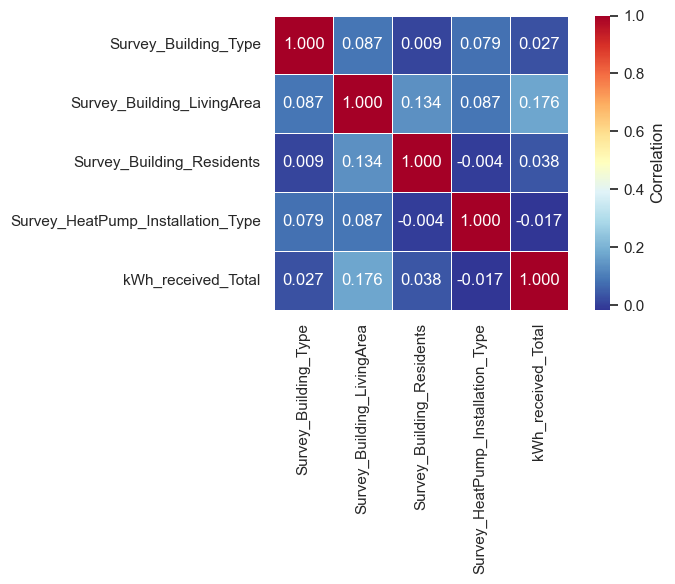

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

heatmap_df = master_df.copy()

categorical_cols = [
    "Survey_Building_Type",
    "Survey_HeatPump_Installation_Type"
]

encoder = LabelEncoder()

for col in categorical_cols:
    if col in heatmap_df.columns:
        heatmap_df[col] = encoder.fit_transform(
            heatmap_df[col].astype(str)
        )

selected_features = [
    "Survey_Building_Type",
    "Survey_Building_LivingArea",
    "Survey_Building_Residents",
    "Survey_HeatPump_Installation_Type",
    "kWh_received_Total"
]

corr_df = heatmap_df[selected_features].dropna()

corr_matrix = corr_df.corr(method="pearson")

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdYlBu_r",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation"}
)


plt.tight_layout()
plt.show()

# Kesimpulan Exploratory Data Analysis (EDA)

Tahap Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik data hasil integrasi sebelum memasuki tahap preprocessing dan pemodelan. Berdasarkan analisis terhadap dataset yang terdiri dari **30.735.648 observasi**, **300 household**, dan **34 variabel**, diperoleh beberapa temuan utama.

Pertama, distribusi jumlah observasi per household menunjukkan bahwa sebagian besar rumah memiliki data yang cukup panjang dan relatif seimbang, dengan jumlah observasi berkisar antara **14.976 hingga 160.800 timestamp** per rumah. Hal ini menunjukkan bahwa data time series yang dimiliki cukup memadai untuk membangun model prediksi konsumsi listrik.

Kedua, analisis missing value menunjukkan bahwa beberapa variabel memiliki tingkat missing yang sangat tinggi, seperti **kWh_received_HeatPump (97,83%)**, **kWh_received_Other (97,82%)**, dan **Survey_DHW_Production_BySolar (91,35%)**. Tingginya missing value pada variabel-variabel tersebut bukan disebabkan oleh kesalahan data, melainkan karena sebagian besar rumah memang tidak memiliki perangkat atau sistem tersebut. Sebaliknya, variabel utama seperti **kWh_received_Total**, **Temperature_avg_hourly**, **Humidity_avg_hourly**, dan sebagian besar metadata memiliki tingkat missing yang sangat rendah sehingga layak digunakan dalam pemodelan.

Ketiga, analisis target variable (**kWh_received_Total**) menunjukkan bahwa distribusi konsumsi listrik bersifat **right-skewed**, di mana sebagian besar konsumsi berada pada nilai rendah dan hanya sedikit observasi yang memiliki konsumsi sangat tinggi. Selain itu, sekitar **3,66% observasi memiliki konsumsi nol**, yang mengindikasikan adanya periode penggunaan listrik yang sangat rendah atau tidak ada konsumsi sama sekali.

Keempat, analisis outlier menggunakan metode **Interquartile Range (IQR)** menunjukkan bahwa sekitar **7,10% data termasuk outlier**. Namun, karena data konsumsi listrik secara alami dapat memiliki nilai ekstrem akibat penggunaan peralatan tertentu, keberadaan outlier ini dianggap sebagai fenomena nyata dan tidak akan dihapus secara langsung. Penanganan outlier akan dipertimbangkan pada tahap preprocessing melalui transformasi atau metode robust.

Kelima, analisis pola temporal menunjukkan adanya **seasonality yang sangat kuat**. Konsumsi listrik tertinggi terjadi pada **musim dingin (Desember–Februari)** dan terendah pada **musim panas (Juni–Agustus)**. Selain itu, pola harian menunjukkan konsumsi listrik meningkat pada **malam hari** dan menurun pada **siang hari**, yang mengindikasikan adanya pengaruh aktivitas penghuni rumah terhadap penggunaan listrik.

Keenam, analisis hubungan dengan variabel cuaca menunjukkan bahwa **Temperature_avg_hourly** memiliki korelasi negatif sedang terhadap konsumsi listrik (**r = -0,325**), yang mengindikasikan bahwa semakin rendah suhu, semakin tinggi konsumsi listrik. Sebaliknya, **Humidity_avg_hourly**, **Precipitation_total_hourly**, dan **WindSpeed_hourly** menunjukkan korelasi yang relatif lemah, namun masih berpotensi memberikan kontribusi pada model non-linear.

Ketujuh, analisis karakteristik rumah menunjukkan bahwa **tipe bangunan (house dan apartment)** memiliki perbedaan konsumsi listrik yang cukup signifikan. Selain itu, **luas bangunan** memiliki hubungan positif terhadap konsumsi listrik, sedangkan **jumlah penghuni rumah** menunjukkan pengaruh yang relatif kecil.

Secara keseluruhan, hasil EDA menunjukkan bahwa faktor yang paling berpengaruh terhadap konsumsi listrik rumah tangga adalah:

1. **Pola waktu (jam, hari, bulan, musim)**.
2. **Suhu udara (temperature)**.
3. **Karakteristik bangunan (building type dan living area)**.
4. **Keberadaan sistem pemanas atau heat pump**.

Berdasarkan temuan tersebut, dataset dinilai memiliki kualitas yang baik dan cukup representatif untuk membangun model prediksi konsumsi listrik. Namun, sebelum memasuki tahap pemodelan, masih diperlukan tahap **data preprocessing dan feature engineering**, terutama untuk menangani missing value, melakukan encoding variabel kategorikal, membuat fitur temporal, serta menentukan fitur-fitur yang paling relevan untuk meningkatkan performa model prediksi.
